In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score


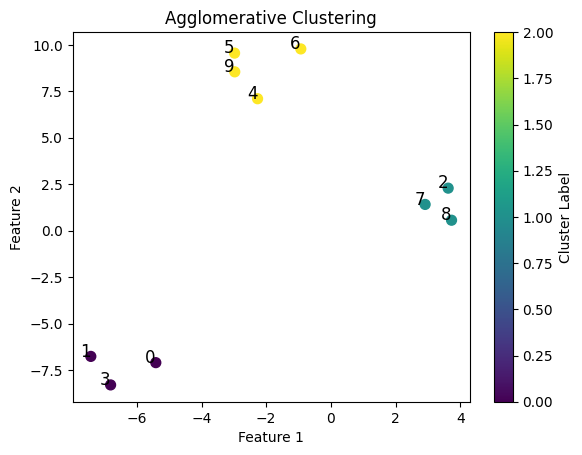

In [2]:
X, y = make_blobs(n_samples=10, centers=3, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="ward")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [3]:
n = X.shape[0]
node = model.cluster_nodes[1]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)) @ X
contrast = X.T@nu
ngrid=100
grid_width=15
stat_grid = np.linspace(-grid_width, grid_width, num=ngrid)

In [4]:
print(node)

ClusterNode(points=[8, 2, 7])


In [5]:
model._approx_log_reference(node, stat_grid, nuisance, contrast)

current step: 6
all winning pairs: [(ClusterNode(points=[5]), ClusterNode(points=[9])), (ClusterNode(points=[2]), ClusterNode(points=[7])), (ClusterNode(points=[0]), ClusterNode(points=[1])), (ClusterNode(points=[3]), ClusterNode(points=[0, 1])), (ClusterNode(points=[4]), ClusterNode(points=[5, 9])), (ClusterNode(points=[8]), ClusterNode(points=[2, 7])), (ClusterNode(points=[6]), ClusterNode(points=[4, 5, 9]))]
level:  6
grid value: -15.0
barr 23.04736315367119
obj -5510.805549949681
conjugate norm: 451.8785666514733
grid value: -14.696969696969697
barr 23.199657170207463
obj -5457.039549549193
conjugate norm: 447.5524196776778
grid value: -14.393939393939394
barr 22.824709210995813
obj -5437.075714467042
conjugate norm: 443.37522594054127
grid value: -14.09090909090909
barr 21.300938181730082
obj -5440.781918277235
conjugate norm: 439.34353606330296
grid value: -13.787878787878787
barr 20.65287982328181
obj -5303.017504454594
conjugate norm: 435.4538246407634
grid value: -13.484848484

array([-104811.23993101, -101696.30998799,  -98752.13076462,
        -95979.70222676,  -93535.23649271,  -91089.38591165,
        -88693.78558644,  -86328.1528412 ,  -84312.68631316,
        -82382.83129272,  -80467.78426439,  -78975.04946947,
        -76015.14635432,  -73766.96439679,  -72452.31627905,
        -71269.24460358,  -70395.01526254,  -69165.14629295,
        -68602.51625222,  -67812.58001015,  -67027.55828359,
        -66389.38090072,  -65801.30199908,  -65298.62618827,
        -64844.71519887,  -64400.57549063,  -64021.53132244,
        -64299.22945358,  -63006.00486977,  -62079.91020642,
        -62057.18789971,  -60080.63310797,  -59375.80122058,
        -57618.83652007,  -57492.95466351,  -56200.96738103,
        -54451.92939023,  -53737.32249017,  -53136.11373862,
        -52851.66213136,  -52476.20784131,  -51942.63480058,
        -51414.02755163,  -51034.29570225,  -49518.94179937,
        -49289.70004002,  -47515.66147364,  -46919.17611233,
        -46130.04475448,

In [6]:
model.merge_inference(node)

current step: 6
all winning pairs: [(ClusterNode(points=[5]), ClusterNode(points=[9])), (ClusterNode(points=[2]), ClusterNode(points=[7])), (ClusterNode(points=[0]), ClusterNode(points=[1])), (ClusterNode(points=[3]), ClusterNode(points=[0, 1])), (ClusterNode(points=[4]), ClusterNode(points=[5, 9])), (ClusterNode(points=[8]), ClusterNode(points=[2, 7])), (ClusterNode(points=[6]), ClusterNode(points=[4, 5, 9]))]
level:  6
grid value: -15.0
barr 23.04736315367119
obj -5510.805549949681
conjugate norm: 451.8785666514733
grid value: -13.421052631578947
barr 20.243059576989964
obj -5326.00487564469
conjugate norm: 430.93003716845783
grid value: -11.842105263157894
barr 19.387492828772462
obj -6255.655345923186
conjugate norm: 413.6155639312518
grid value: -10.263157894736842
barr 17.48597701551694
obj -9428.527618934571
conjugate norm: 399.4049556774031
grid value: -8.68421052631579
barr 17.088146751173362
obj -9411.644139799833
conjugate norm: 387.7720261451659
grid value: -7.1052631578947

(np.float64(1.0),
 array([ 0.4608504, -1.2882836]),
 np.float64(1.3682316082457424),
 array([-5.95526413e+04, -5.92452149e+04, -5.89392295e+04, -5.86346850e+04,
        -5.83315814e+04, -5.80299189e+04, -5.77296972e+04, -5.74309165e+04,
        -5.71335768e+04, -5.68376780e+04, -5.65432202e+04, -5.62502034e+04,
        -5.59586275e+04, -5.56684925e+04, -5.53797985e+04, -5.50925455e+04,
        -5.48067334e+04, -5.45223623e+04, -5.42394321e+04, -5.39579429e+04,
        -5.36778946e+04, -5.33992873e+04, -5.31221209e+04, -5.28463955e+04,
        -5.25721111e+04, -5.22992676e+04, -5.20278651e+04, -5.17579035e+04,
        -5.14893828e+04, -5.12223032e+04, -5.09566645e+04, -5.06924667e+04,
        -5.04297099e+04, -5.01683940e+04, -4.99085191e+04, -4.96500852e+04,
        -4.93930922e+04, -4.91375402e+04, -4.88834291e+04, -4.86307590e+04,
        -4.83795298e+04, -4.81297416e+04, -4.78813943e+04, -4.76344880e+04,
        -4.73890227e+04, -4.71449983e+04, -4.69024148e+04, -4.66612723e+04,
   

In [7]:
nu

array([ 0. ,  0. , -0.5,  0. ,  0. ,  0. ,  0. , -0.5,  1. ,  0. ])

In [8]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

Distance Log:
(ClusterNode(points=[0]), ClusterNode(points=[1])): 2.0380364931244994
(ClusterNode(points=[0]), ClusterNode(points=[2])): 13.037418962158593
(ClusterNode(points=[0]), ClusterNode(points=[3])): 1.8418128827045737
(ClusterNode(points=[0]), ClusterNode(points=[4])): 14.551211837000686
(ClusterNode(points=[0]), ClusterNode(points=[5])): 16.83975525993707
(ClusterNode(points=[0]), ClusterNode(points=[6])): 17.472763390969146
(ClusterNode(points=[0]), ClusterNode(points=[7])): 11.912454405048726
(ClusterNode(points=[0]), ClusterNode(points=[8])): 11.934209188039876
(ClusterNode(points=[0]), ClusterNode(points=[9])): 15.843668027053912
(ClusterNode(points=[1]), ClusterNode(points=[2])): 14.288035244679854
(ClusterNode(points=[1]), ClusterNode(points=[3])): 1.653093983207061
(ClusterNode(points=[1]), ClusterNode(points=[4])): 14.797789518418515
(ClusterNode(points=[1]), ClusterNode(points=[5])): 16.920413362187247
(ClusterNode(points=[1]), ClusterNode(points=[6])): 17.7793395019

In [9]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")


Existing Clusters Log:
Merge: (ClusterNode(points=[5]), ClusterNode(points=[9])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9])]
Merge: (ClusterNode(points=[2]), ClusterNode(points=[7])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[5, 9])]
Merge: (ClusterNode(points=[0]), ClusterNode(points=[1])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[6]), ClusterNode(points=[8]), ClusterNode(points=[5, 9]), ClusterNode(points=[2, 7])]
Merge: (ClusterNode(points=[3]), ClusterNode(points=[0, 1])) -> Clusters: [C

In [10]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")
    break


Randomization Log:
1: {(ClusterNode(points=[0]), ClusterNode(points=[1])): -0.8145394301676273, (ClusterNode(points=[0]), ClusterNode(points=[2])): 0.7229009872762492, (ClusterNode(points=[0]), ClusterNode(points=[3])): 1.8629667312592024, (ClusterNode(points=[0]), ClusterNode(points=[4])): -0.32393288233513523, (ClusterNode(points=[0]), ClusterNode(points=[5])): -0.20720473473669626, (ClusterNode(points=[0]), ClusterNode(points=[6])): 0.5160900594828833, (ClusterNode(points=[0]), ClusterNode(points=[7])): -0.38766927398336987, (ClusterNode(points=[0]), ClusterNode(points=[8])): -1.676137582253771, (ClusterNode(points=[0]), ClusterNode(points=[9])): -0.8017236410110511, (ClusterNode(points=[1]), ClusterNode(points=[2])): 0.7551718637653158, (ClusterNode(points=[1]), ClusterNode(points=[3])): -0.4735246172956504, (ClusterNode(points=[1]), ClusterNode(points=[4])): 1.3114859706126571, (ClusterNode(points=[1]), ClusterNode(points=[5])): 0.5269485527872482, (ClusterNode(points=[1]), Cluste

In [11]:
np.shape(nuisance)

(10, 2)

In [12]:
np.shape(nu)

(10,)